# Action-Angle Coordinates: Adiabatic Approximation

The adiabatic approximation (`actionAngleAdiabatic`) separates the radial
and vertical motions, computing $J_z$ at each radius while assuming that
the radial motion is slow compared to the vertical oscillation
(e.g., [Binney & McMillan 2010](http://adsabs.harvard.edu/abs/2010MNRAS.401.2318B)).
This is fast but less accurate than the [Staeckel method](staeckel.ipynb) for orbits with
large vertical excursions.

<div class="alert alert-warning">

**Warning:** Frequencies and angles using the adiabatic approximation are
**not implemented** at this time. Use the [Staeckel approximation](staeckel.ipynb) if you need
frequencies and angles.

</div>

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
from galpy.potential import MWPotential2014
from galpy.orbit import Orbit

## Setup

Setup is straightforward. Using `c=True` gives a significant speed-up
(about 50x for single evaluations, 200x for arrays):

In [2]:
from galpy.actionAngle import actionAngleAdiabatic

aAA = actionAngleAdiabatic(pot=MWPotential2014, c=True)

## Computing actions

Calling the object returns $(J_R, L_z, J_z)$:

In [3]:
jr_ad, jphi_ad, jz_ad = aAA(1.0, 0.1, 1.1, 0.0, 0.05)
print(f"J_R = {jr_ad.item():.6f}, L_z = {jphi_ad.item():.6f}, J_z = {jz_ad.item():.6f}")

J_R = 0.013525, L_z = 1.100000, J_z = 0.000469


## Action conservation for a thin-disk orbit

The adiabatic approximation works well for orbits that stay close to the
plane. Let's check action conservation for a near-circular orbit:

In [4]:
o = Orbit([1.0, 0.1, 1.1, 0.0, 0.05])
ts = numpy.linspace(0, 100, 1001)
o.integrate(ts, MWPotential2014)

print(f"Maximum height: {o.zmax() * 8.0:.2f} kpc (for R_0 = 8 kpc)")

Maximum height: 0.18 kpc (for R_0 = 8 kpc)


Now compute the actions along the orbit and check conservation:

Text(0.5, 1.0, 'Adiabatic: action conservation (thin-disk orbit)')

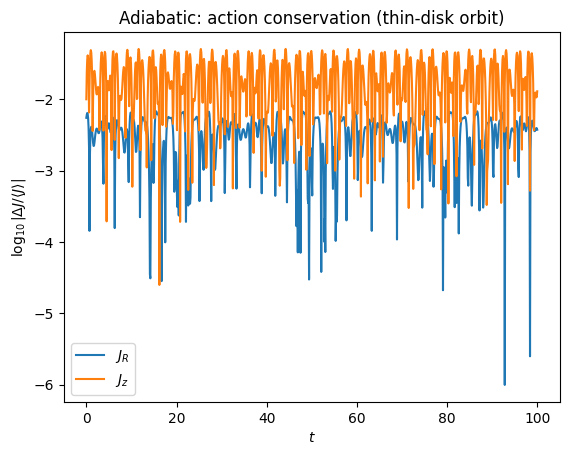

In [5]:
js = aAA(o.R(ts), o.vR(ts), o.vT(ts), o.z(ts), o.vz(ts))

plt.plot(ts, numpy.log10(numpy.fabs((js[0] - numpy.mean(js[0])) / numpy.mean(js[0]))))
plt.plot(ts, numpy.log10(numpy.fabs((js[2] - numpy.mean(js[2])) / numpy.mean(js[2]))))
plt.xlabel(r"$t$")
plt.ylabel(r"$\log_{10}|\Delta J / \langle J \rangle|$")
plt.legend([r"$J_R$", r"$J_z$"])
plt.title("Adiabatic: action conservation (thin-disk orbit)")

The radial action is conserved to about half a percent, the vertical action
to about two percent.

## Comparison with Staeckel for thin-disk orbits

For thin-disk orbits, the adiabatic and Staeckel approximations agree well:

In [6]:
from galpy.actionAngle import actionAngleStaeckel

aAS = actionAngleStaeckel(pot=MWPotential2014, delta=0.4, c=True)

jr_st, jphi_st, jz_st = aAS(1.0, 0.1, 1.1, 0.0, 0.05)

print("Method       J_R        J_z")
print(f"Adiabatic:   {jr_ad.item():.6f}   {jz_ad.item():.6f}")
print(f"Staeckel:    {jr_st.item():.6f}   {jz_st.item():.6f}")

Method       J_R        J_z
Adiabatic:   0.013525   0.000469
Staeckel:    0.013636   0.000463


## Failure for high-z orbits

The adiabatic approximation breaks down for orbits that reach distances
of a kpc and more from the plane. Let's examine a higher-z orbit:

In [7]:
o_hz = Orbit([1.0, 0.1, 1.1, 0.0, 0.25])
o_hz.integrate(ts, MWPotential2014)

print(f"Maximum height: {o_hz.zmax() * 8.0:.2f} kpc (for R_0 = 8 kpc)")

Maximum height: 1.35 kpc (for R_0 = 8 kpc)


Compute actions along this higher-z orbit:

Text(0.5, 1.0, 'Adiabatic: action conservation (high-z orbit)')

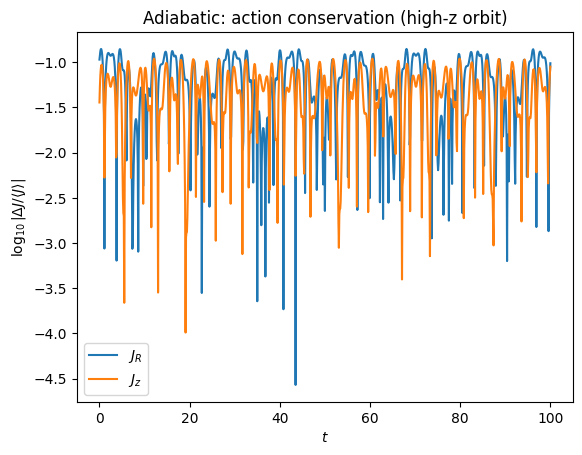

In [8]:
js_hz = aAA(o_hz.R(ts), o_hz.vR(ts), o_hz.vT(ts), o_hz.z(ts), o_hz.vz(ts))

plt.plot(
    ts,
    numpy.log10(numpy.fabs((js_hz[0] - numpy.mean(js_hz[0])) / numpy.mean(js_hz[0]))),
)
plt.plot(
    ts,
    numpy.log10(numpy.fabs((js_hz[2] - numpy.mean(js_hz[2])) / numpy.mean(js_hz[2]))),
)
plt.xlabel(r"$t$")
plt.ylabel(r"$\log_{10}|\Delta J / \langle J \rangle|$")
plt.legend([r"$J_R$", r"$J_z$"])
plt.title("Adiabatic: action conservation (high-z orbit)")

The radial action is now only conserved to about ten percent and the
vertical action to approximately five percent. The [Staeckel approximation](staeckel.ipynb)
does much better for the same orbit (better than a percent for $J_R$
and a fraction of a percent for $J_z$).

## Grid-based interpolation: actionAngleAdiabaticGrid

Like the Staeckel method, the adiabatic approximation can be sped up
with a precomputed grid. The grid-based calculation can be significantly
faster than even the direct C implementation (up to 150x for large arrays):

In [9]:
from galpy.actionAngle import actionAngleAdiabaticGrid

aAAG = actionAngleAdiabaticGrid(
    pot=MWPotential2014, c=True, nR=31, nEz=31, nEr=51, nLz=51
)

Compare the grid-based and direct calculations:

In [10]:
jr_direct, _, jz_direct = aAA(1.0, 0.1, 1.1, 0.0, 0.05)
jr_grid, _, jz_grid = aAAG(1.0, 0.1, 1.1, 0.0, 0.05)

print(f"J_R: direct = {jr_direct.item():.6f}, grid = {jr_grid.item():.6f}")
print(f"J_z: direct = {jz_direct.item():.6f}, grid = {jz_grid.item():.6f}")

J_R: direct = 0.013525, grid = 0.013527
J_z: direct = 0.000469, grid = 0.000477


The grid-based and direct calculations agree well. For `MWPotential2014`
and other more complicated potentials (such as those involving a
double-exponential disk), the overhead of setting up the grid is worth it
when evaluating more than a few thousand actions.